In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import lime
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
import streamlit as st

In [10]:
df=pd.read_excel('Crop_recommendation.xlsx',engine='openpyxl')

In [11]:
df.shape

(2200, 8)

In [12]:
df.head(1)

,N,P,K,temperature,humidity,ph,Unnamed: 6,label
0,90,42,43,20.879744,82.002744,6.502985,NaN,rice


N - ratio of Nitrogen content in soil
P - ratio of Phosphorous content in soil
K - ratio of Potassium content in soil
temperature - temperature in degree Celsius
humidity - relative humidity in %
ph - ph value of the soil

In [13]:
label_counts = df['label'].value_counts()
print(label_counts)
print(f'type of categories:{label_counts.size}')

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64
type of categories:22


In [14]:
missing=df.isna().sum(axis=0)
missing

N                 0
P                 0
K                 0
temperature       0
humidity          0
ph                0
Unnamed: 6     2200
label             0
dtype: int64

In [15]:
df.drop(['Unnamed: 6'],axis=1,inplace=True)
df = pd.DataFrame(df)

In [16]:
X=df.drop(['label'],axis=1)
y=df['label']

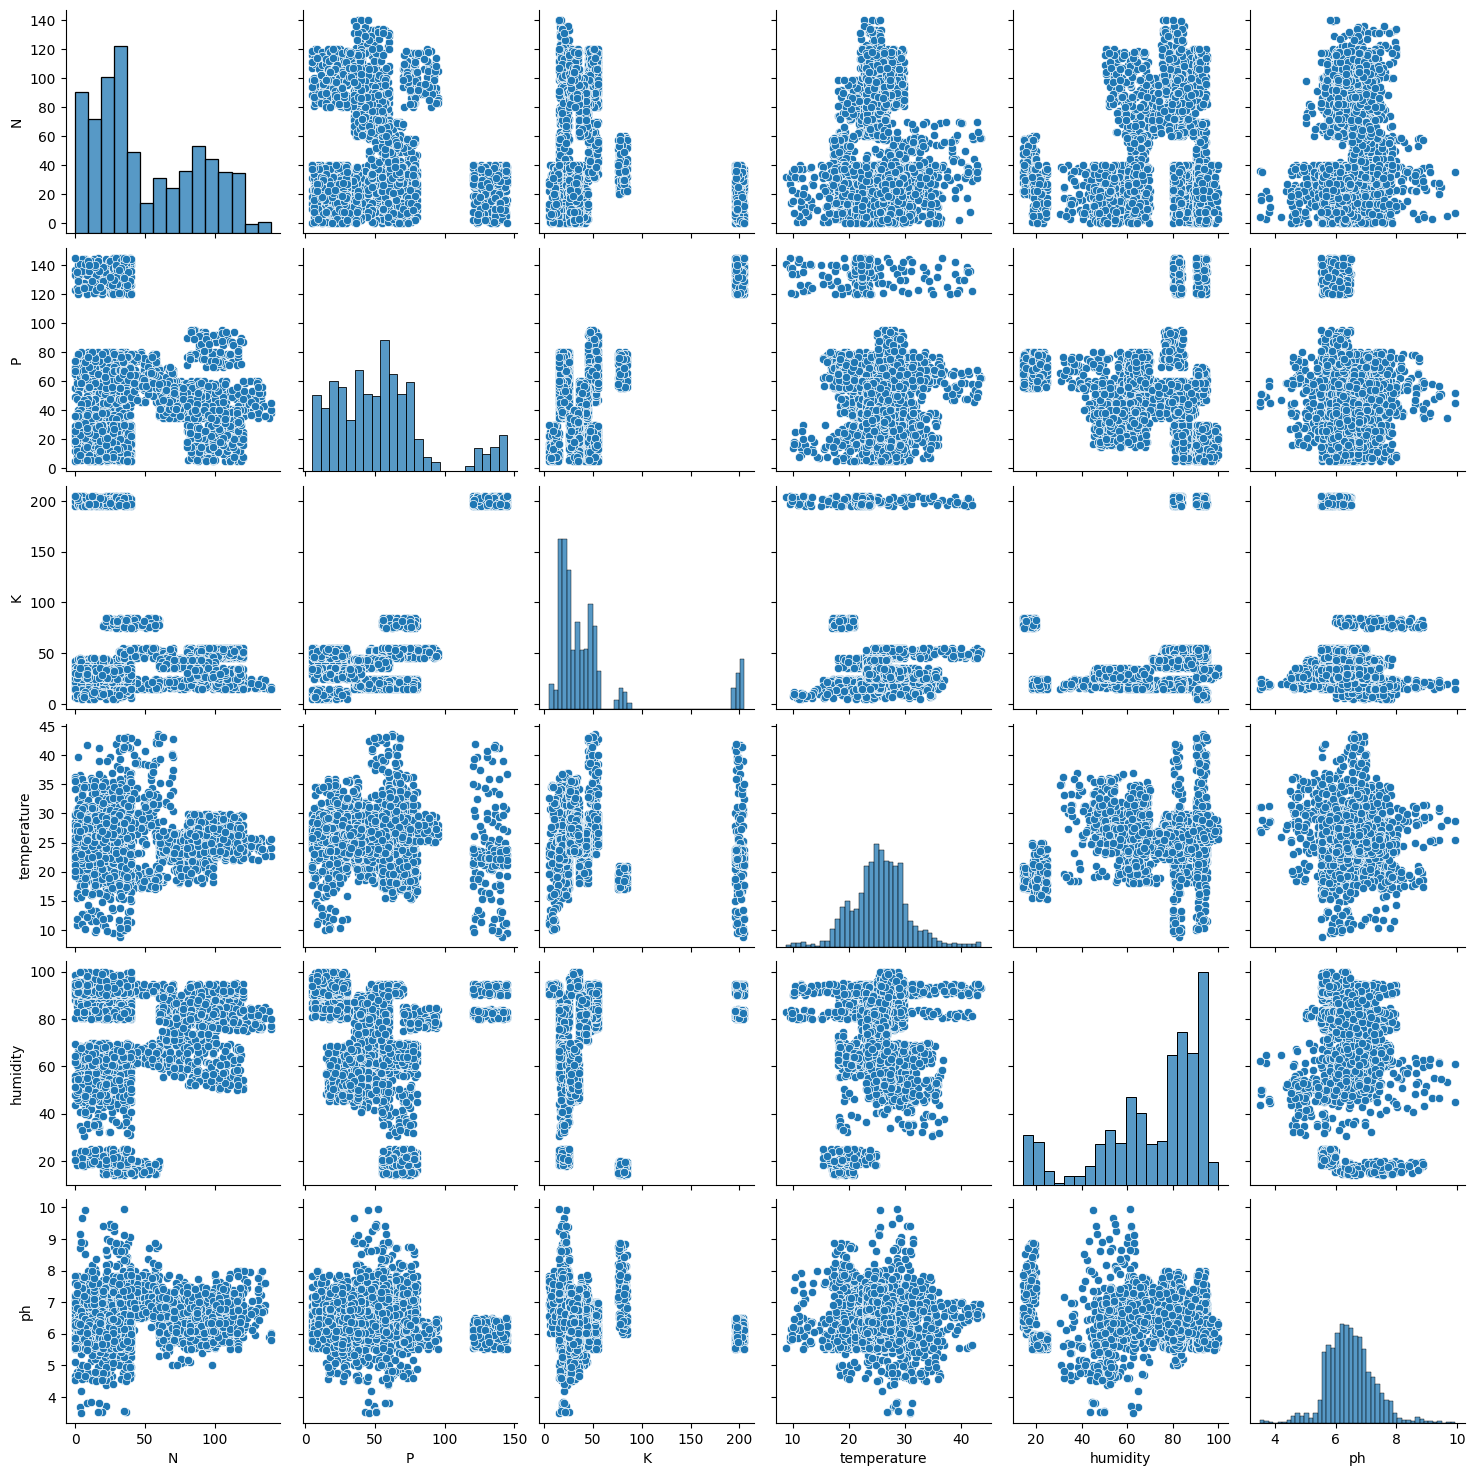

In [17]:
sns.pairplot(df[['N', 'P', 'K', 'temperature', 'humidity', 'ph']], diag_kind='hist')
plt.show()

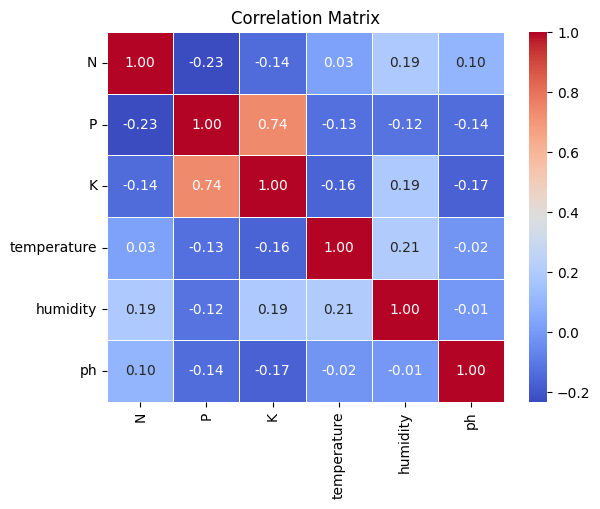

In [18]:
# Compute correlation matrix
corr = df[['N', 'P', 'K', 'temperature', 'humidity', 'ph']].corr()

# Plot heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()


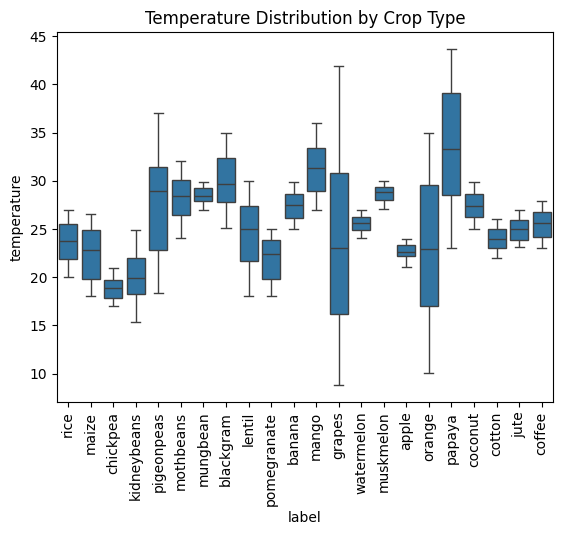

In [19]:
sns.boxplot(x='label', y='temperature', data=df)
plt.title('Temperature Distribution by Crop Type')
plt.xticks(rotation=90)  
plt.show()

In [20]:
from scipy.stats import zscore

z_scores = zscore(df[['N', 'P', 'K', 'temperature', 'humidity', 'ph']])

outliers = (np.abs(z_scores) > 3)
print(f"Outliers for each feature: \n{outliers}")

Outliers for each feature: 
[[False False False False False False]
 [False False False False False False]
 [False False False False False False]
 ...
 [False False False False False False]
 [False False False False False False]
 [False False False False False False]]


In [21]:
label_encoder = LabelEncoder()
y= label_encoder.fit_transform(y)

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

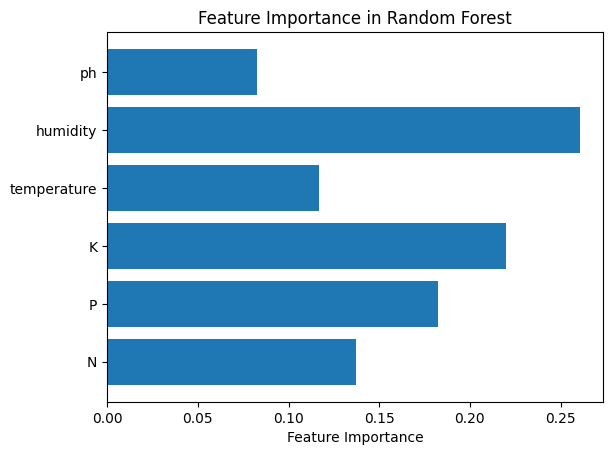

In [22]:
model = RandomForestClassifier(random_state=42,n_estimators=100)
model.fit(X_train, y_train)
feature_importances = model.feature_importances_

plt.barh(df.columns[:-1], feature_importances)
plt.xlabel("Feature Importance")
plt.title("Feature Importance in Random Forest")
plt.show()

In [23]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
}

xgb = XGBClassifier(eval_metric='mlogloss', random_state=42)

# Grid Search with 3-fold cross-validation
grid_search = GridSearchCV(xgb, param_grid, cv=3, verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

# Best model and evaluation
best_xgb = grid_search.best_estimator_
y_pred = best_xgb.predict(X_test)
print("Best Parameters:", grid_search.best_params_)

Fitting 3 folds for each of 54 candidates, totalling 162 fits
Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 50, 'subsample': 1.0}


---------------grid-search results----------------

Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 50, 'subsample': 1.0}


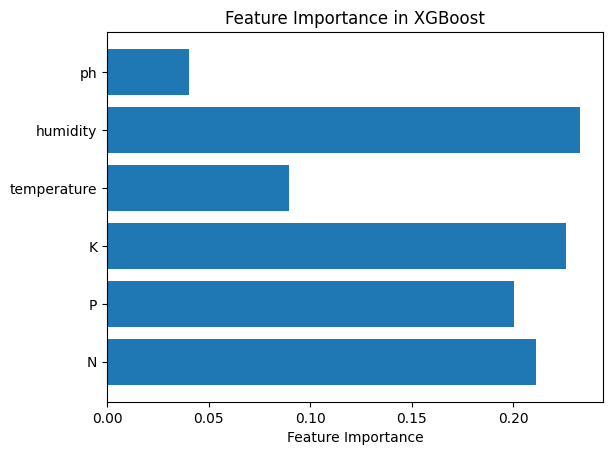

In [24]:
feature_importances = best_xgb.feature_importances_
plt.barh(df.columns[:-1], feature_importances)
plt.xlabel("Feature Importance")
plt.title("Feature Importance in XGBoost")
plt.show()

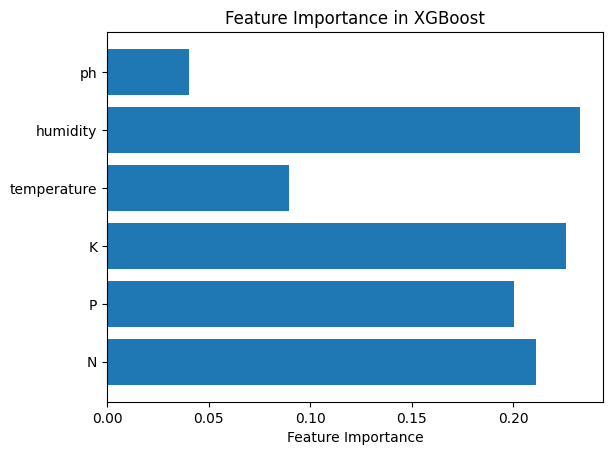

In [25]:
feature_importances = best_xgb.feature_importances_
plt.barh(df.columns[:-1], feature_importances)
plt.xlabel("Feature Importance")
plt.title("Feature Importance in XGBoost")
plt.show()

In [26]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression(max_iter=1000)
lr.fit(X_train,y_train)

/home/linux/coding/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [27]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy RandomForest:", accuracy)
y_pred_xgb = best_xgb.predict(X_test)
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print("Accuracy XGBoost:", accuracy_xgb)
y_pred=lr.predict(X_test)
accuracy_score=accuracy_score(y_test,y_pred)
print("Accuracy LogisticRegression:", accuracy_score)

Accuracy RandomForest: 0.9681818181818181
Accuracy XGBoost: 0.9681818181818181
Accuracy LogisticRegression: 0.9090909090909091


XAI

In [28]:
import lime
import lime.lime_tabular
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=label_encoder.classes_,
    mode="classification"
)
instance_idx = 0
instance_to_explain = X_test.iloc[instance_idx]
true_class_encoded = y_test[instance_idx]
true_class_name = label_encoder.inverse_transform([true_class_encoded])[0]

print(f"Explaining prediction for instance {instance_idx}:")
print(f"True Crop: {true_class_name}")
print("-" * 30)
print("Instance Feature Values:")
print(instance_to_explain)
print("-" * 30)

explanation = explainer.explain_instance(
    data_row=instance_to_explain.values,
    predict_fn=model.predict_proba,
    num_features=len(X.columns),
    num_samples=5000
)
print("LIME Explanation:")
for exp in explanation.as_list():
    print(exp)


Explaining prediction for instance 0:
True Crop: orange
------------------------------
Instance Feature Values:
N              13.000000
P              23.000000
K               6.000000
temperature    23.961476
humidity       90.264080
ph              7.365338
Name: 1609, dtype: float64
------------------------------
LIME Explanation:
('P <= 28.00', -0.043985177600538494)
('N <= 21.00', -0.0350743235872226)
('K <= 20.00', -0.028133978551953907)
('humidity > 89.91', -0.017769809871442933)
('ph > 6.93', -0.009964836332543867)
('22.78 < temperature <= 25.52', -0.0029855519013723165)


/home/linux/coding/venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


SHAP

In [29]:
import shap
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
class_names = label_encoder.classes_
if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap_values_list = [shap_values[:, :, i] for i in range(shap_values.shape[2])]

else:
    shap_values_list = shap_values

(a) Summary Plot (Global Feature Importance)

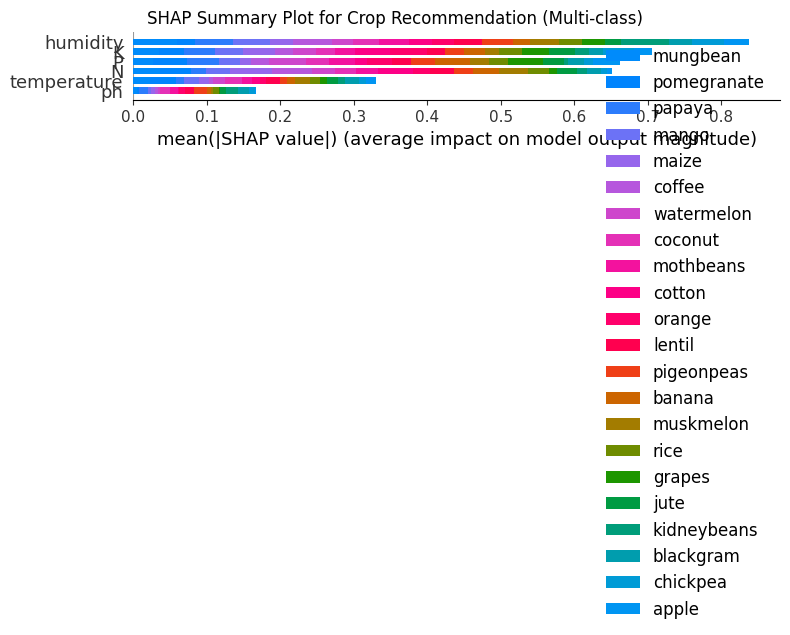

In [30]:
shap.summary_plot(
        shap_values_list,
        X_test, 
        feature_names=X_test.columns.tolist(), 
        class_names=class_names, 
        show=False 
)
plt.suptitle('SHAP Summary Plot for Crop Recommendation (Multi-class)', y=1.02)
plt.show()

(b) Force Plot (Explanation for a Single Instance)

2025-09-16 18:13:04.092 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-09-16 18:13:04.093 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-09-16 18:13:04.295 
  command:

    streamlit run /home/linux/coding/venv/lib/python3.13/site-packages/ipykernel_launcher.py [ARGUMENTS]
2025-09-16 18:13:04.296 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-09-16 18:13:04.296 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-09-16 18:13:04.297 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-09-16 18:13:04.297 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored

DeltaGenerator()

<Figure size 1000x300 with 0 Axes>

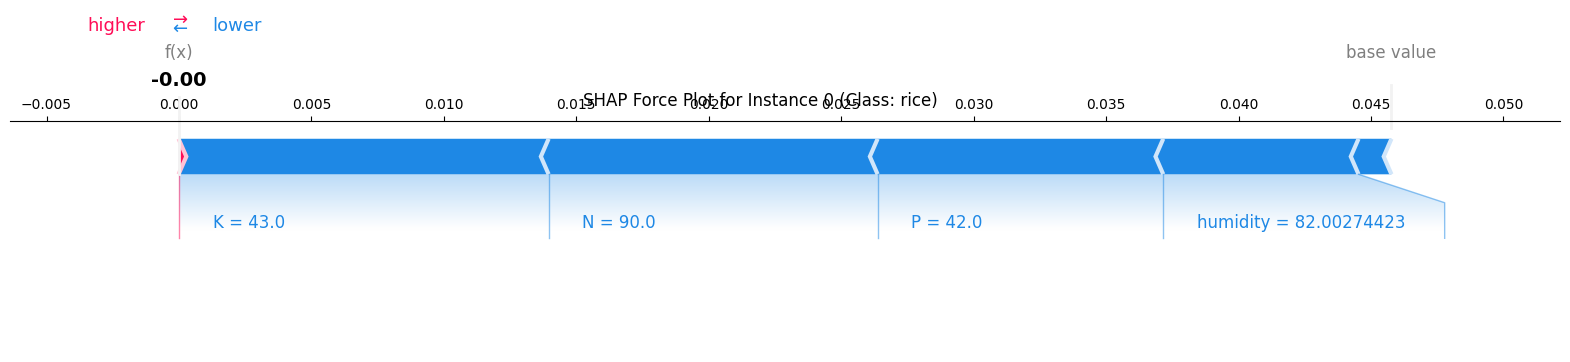

In [31]:
st.set_page_config(page_title="SHAP Crop Classifier Explainer", layout="wide")
st.title("🌾 SHAP Explanation for Crop Classification (Random Forest)")

instance_idx_to_explain = st.slider("Select an instance to explain", 0, len(X)-1, 0)
class_idx_to_explain = y[instance_idx_to_explain]
chosen_class_name = class_names[class_idx_to_explain]

st.write(f"**Explaining prediction for instance {instance_idx_to_explain} toward class '{chosen_class_name}'**")
st.write("🔍 Feature values for the instance:")
st.dataframe(X.iloc[[instance_idx_to_explain]])

# Generate SHAP force plot
# shap.initjs()
fig = plt.figure(figsize=(10, 3))
shap.force_plot(
    explainer.expected_value[class_idx_to_explain],
    shap_values_list[class_idx_to_explain][instance_idx_to_explain, :],
    X.iloc[instance_idx_to_explain, :],
    feature_names=X.columns.tolist(),
    matplotlib=True,
    show=False
)
plt.suptitle(f'SHAP Force Plot for Instance {instance_idx_to_explain} (Class: {chosen_class_name})', fontsize=12)
st.pyplot(fig)

(c) Dependence Plot (Feature Dependence and Interaction)

Plotting dependence for feature 'N' for class 'apple'


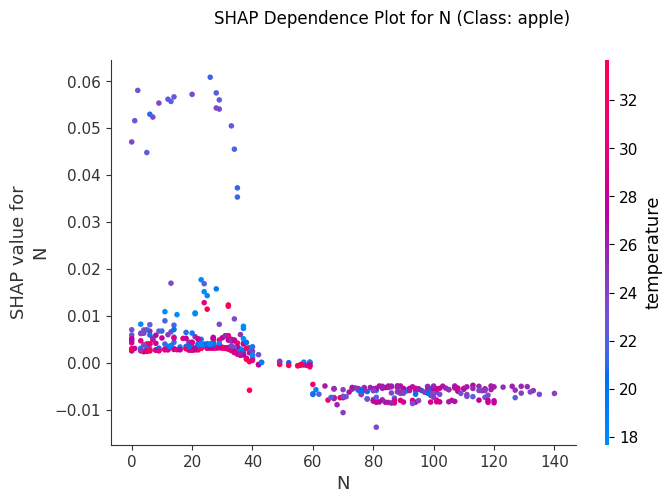

In [32]:
# Choose a feature to plot 
feature_to_plot = 'N'
# Choose a class 
class_idx_for_dependence = 0
if class_idx_for_dependence < len(class_names):
    chosen_class_name_dep = class_names[class_idx_for_dependence]
    print(f"Plotting dependence for feature '{feature_to_plot}' for class '{chosen_class_name_dep}'")

    shap.dependence_plot(
        feature_to_plot,
        shap_values_list[class_idx_for_dependence],
        X_test,
        feature_names=X_test.columns.tolist(),
        interaction_index='temperature', 
        show=False
    )
    plt.suptitle(f'SHAP Dependence Plot for {feature_to_plot} (Class: {chosen_class_name_dep})')
    plt.show()    

(d) Waterfall Plot (Explanation for a Single Instance, cumulative)

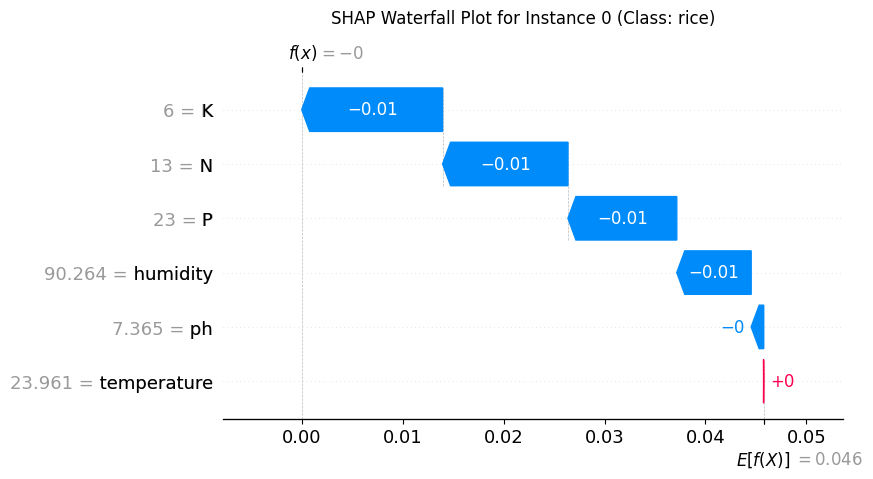

In [33]:

shap.initjs() 
explanation_object = shap.Explanation(
    values=shap_values_list[class_idx_to_explain][instance_idx_to_explain, :],
    base_values=explainer.expected_value[class_idx_to_explain], 
    data=X_test.iloc[instance_idx_to_explain, :].values,
    feature_names=X_test.columns.tolist()
)

shap.waterfall_plot(explanation_object, show=False)
plt.suptitle(f'SHAP Waterfall Plot for Instance {instance_idx_to_explain} (Class: {chosen_class_name})', y=1.02)
plt.show()


In [34]:
import shap
import pickle

# For logistic model
explainer_logistic = shap.Explainer(logistic_model.predict, X_train)
pickle.dump(explainer_logistic, open('xai/shap_logistic.pkl', 'wb'))

# For xgboost model
explainer_xgb = shap.Explainer(xgb_model, X_train)
pickle.dump(explainer_xgb, open('xai/shap_xgboost.pkl', 'wb'))


NameError: name 'logistic_model' is not defined

Exception ignored in: <function ResourceTracker.__del__ at 0x7f7019474d60>
Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7f4d53a88d60>
Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7f8ff6984d60>
Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/reso